# Final Project
## - Tate Tarelli

Setting up the environmet by importing calculation, plotting and fits modules.

In [1]:
import numpy as np
import sep

In [2]:
import astropy.io.fits
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['figure.figsize'] = [10., 8.]

Then, we'll get the data from the .fits file and show it along with a color bar.

In [3]:
data = astropy.io.fits.getdata("hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits")

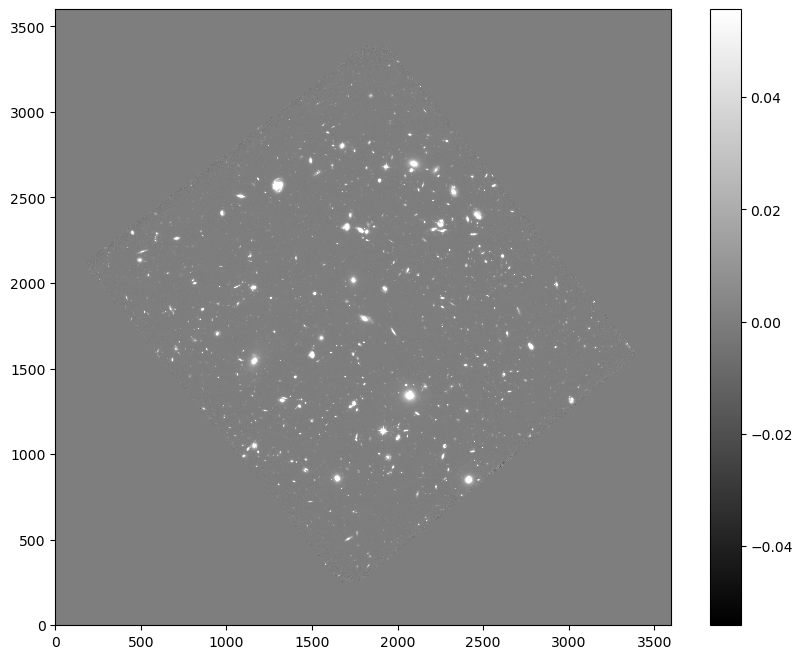

In [4]:
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();

In [5]:
dimensions = data.shape
print(dimensions)
data = data.astype(data.dtype.newbyteorder('='))
bkg = sep.Background(data, bw=64, bh=64, fw=3, fh=3)

(3600, 3600)


Then the background and noise will be retireved and the background will be measured and then shown.

In [6]:
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


In [7]:
bkg_image = bkg.back()

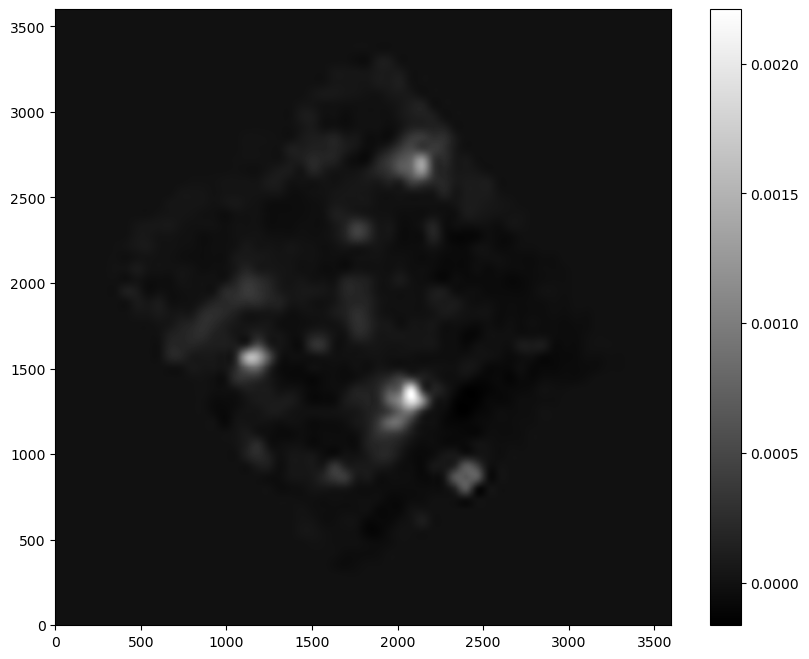

In [8]:
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

Then, the noise will be evaluated and then shown.

In [9]:
bkg_rms = bkg.rms()

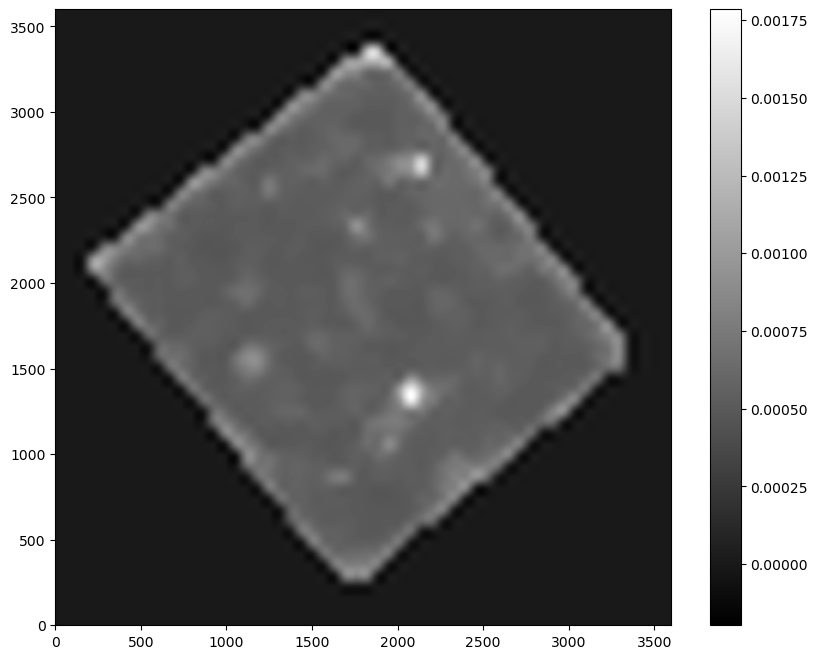

In [10]:
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

The background will be subtracted from the data and using this new data, the number of objects will be counted.

In [11]:
data_sub = data - bkg

In [12]:
# sep.set_extract_pixstack(13000000)
objects = sep.extract(data_sub, 500, err=bkg.globalrms)

In [13]:
len(objects)

42

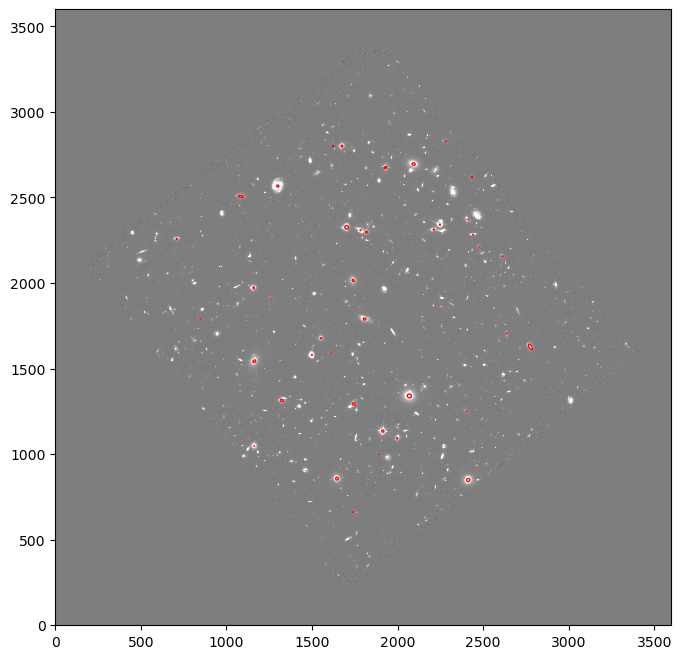

In [14]:
from matplotlib.patches import Ellipse

# plot background-subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

Finally, we’ll perform simple circular aperture photometry with a 3 pixel radius at the locations of the objects

In [15]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

In [16]:
for i in range(len(objects)):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 8.213605 +/- 2.865940
object 1: flux = 65.752841 +/- 8.108813
object 2: flux = 72.310017 +/- 8.503530
object 3: flux = 6.587839 +/- 2.566680
object 4: flux = 6.952094 +/- 2.636684
object 5: flux = 8.874832 +/- 2.979067
object 6: flux = 806.296798 +/- 28.395366
object 7: flux = 6.804393 +/- 2.608525
object 8: flux = 51.914784 +/- 7.205192
object 9: flux = 45.714075 +/- 6.761219
object 10: flux = 77.662708 +/- 8.812645
object 11: flux = 56.573325 +/- 7.521525
object 12: flux = 7.627842 +/- 2.761856
object 13: flux = 5.497649 +/- 2.344708
object 14: flux = 24.595078 +/- 4.959343
object 15: flux = 10.064522 +/- 3.172464
object 16: flux = 7.368699 +/- 2.714536
object 17: flux = 5.605835 +/- 2.367666
object 18: flux = 22.030602 +/- 4.693678
object 19: flux = 6.359988 +/- 2.521903
object 20: flux = 6.400650 +/- 2.529952
object 21: flux = 10.607402 +/- 3.256902
object 22: flux = 35.996201 +/- 5.999684
object 23: flux = 8.781281 +/- 2.963324
object 24: flux = 6.574415 +/- 2.564

## Question: How many sources (stars) do you find in the data?
## Answer: 42 sources found with a threshold of 500

Text(0, 0.5, 'Sources')

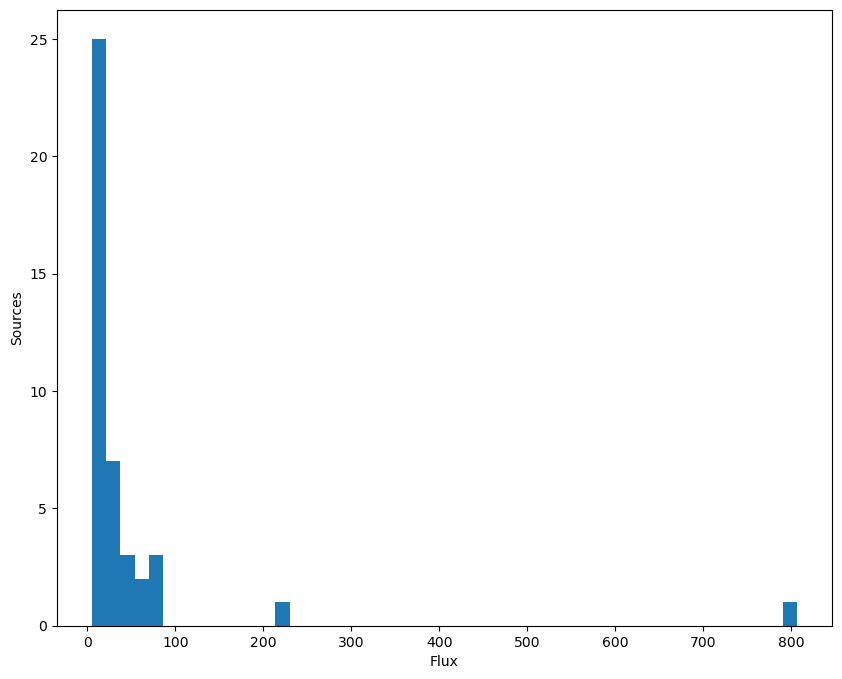

In [17]:
plt.hist(flux, bins = 50)
plt.xlabel("Flux")
plt.ylabel("Sources")

In [18]:
flux_std = np.std(flux)
flux_mean = np.mean(flux)
flux_med = np.median(flux)
print(flux_std)
print(flux_mean)
print(flux_med)

124.13184333057917
46.0511623340313
10.335961549878121


## Mean: 46.0511623340313
## Median: 10.335961549878121
## Standard Deviation: 124.13184333057917

## Question : What is the largest outlier in the distribution; how many standard deviations is it away from the mean?
## Answer: The largest outlier in the distribution is object 6 with a flux of 806.296798. It is 6.124501298521251 standard deviations away from the mean.

In [20]:
largest = 806.296798
temp = largest - flux_mean
answer = temp / flux_std
print(answer)

6.124501298521251
